# Transfer Learning for COVID-19 Image Classification using ResNet50

## Overview

This notebook implements **transfer learning** using ResNet50 pre-trained on ImageNet for COVID-19 chest X-ray classification. Transfer learning leverages the pre-trained model to improve performance and address class imbalance issues.

### Key Features:
- **Pre-trained Model**: ResNet50 from Keras Applications
- **Two-Phase Training**: Feature extraction (frozen base) to Fine-tuning (unfrozen layers)
- **Class Imbalance Handling**: Class weights and balanced loss functions
- **Performance Comparison**: Compare with custom CNN baseline

### Training Strategy:
1. **Phase 1**: Freeze pre-trained ResNet50 base, train only custom classification head
2. **Phase 2**: Unfreeze top layers of ResNet50, fine-tune with lower learning rate


In [31]:
# Import TensorFlow and verify GPU
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

# Configure GPU (if available)
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"GPU detected: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
else:
    print("No GPU detected - will use CPU")


TensorFlow version: 2.20.0
GPU detected: /physical_device:GPU:0


In [32]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import losses, optimizers
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, BatchNormalization, 
    Dropout, Input
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, 
    CSVLogger, TensorBoard
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')


## 1. Configuration & Setup


In [33]:
# Configuration and hyperparameters for Transfer Learning

# Data paths
DATA_DIR = Path('data')
TRAIN_SPLIT_CSV = DATA_DIR / 'train_split.csv'
VAL_SPLIT_CSV = DATA_DIR / 'val_split.csv'
MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# Model hyperparameters
IMG_SIZE = 256  # Images are already 256px
BATCH_SIZE = 32  # Smaller batch size for pre-trained models (larger memory footprint)
EPOCHS_PHASE1 = 30  # Feature extraction phase
EPOCHS_PHASE2 = 20  # Fine-tuning phase
LEARNING_RATE_PHASE1 = 1e-3  # Higher LR for training new head
LEARNING_RATE_PHASE2 = 1e-5  # Lower LR for fine-tuning
NUM_CLASSES = 4  # Typical, Negative, Atypical, Indeterminate

# Transfer learning configuration
FINE_TUNE_LAYERS = None  # Number of layers to unfreeze in Phase 2 (None = auto)

# Class labels mapping
CLASS_LABELS = {
    0: 'Negative for Pneumonia',
    1: 'Typical Appearance',
    2: 'Indeterminate Appearance',
    3: 'Atypical Appearance'
}

# Model save paths
MODEL_DIR_TRANSFER = MODEL_DIR / 'transfer_learning'
MODEL_DIR_TRANSFER.mkdir(exist_ok=True)
MODEL_WEIGHTS_PATH_PHASE1 = MODEL_DIR_TRANSFER / 'resnet50_phase1.weights.h5'
MODEL_WEIGHTS_PATH_PHASE2 = MODEL_DIR_TRANSFER / 'resnet50_phase2.weights.h5'

print("=" * 60)
print("TRANSFER LEARNING CONFIGURATION")
print("=" * 60)
print(f"Base Model: ResNet50")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Phase 1 epochs: {EPOCHS_PHASE1} (Feature Extraction)")
print(f"Phase 2 epochs: {EPOCHS_PHASE2} (Fine-tuning)")
print(f"Phase 1 learning rate: {LEARNING_RATE_PHASE1}")
print(f"Phase 2 learning rate: {LEARNING_RATE_PHASE2}")
print(f"Number of classes: {NUM_CLASSES}")
print("=" * 60)


TRANSFER LEARNING CONFIGURATION
Base Model: ResNet50
Image size: 256x256
Batch size: 32
Phase 1 epochs: 30 (Feature Extraction)
Phase 2 epochs: 20 (Fine-tuning)
Phase 1 learning rate: 0.001
Phase 2 learning rate: 1e-05
Number of classes: 4


## 2. Data Loading & Preprocessing


In [34]:
# Load train/val splits
train_df = pd.read_csv(TRAIN_SPLIT_CSV)
val_df = pd.read_csv(VAL_SPLIT_CSV)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"\nClass distribution in training set:")
print(train_df['label_id'].value_counts())
print(f"\nClass distribution in validation set:")
print(val_df['label_id'].value_counts())

# Display first few rows
print("\nTraining data sample:")
print(train_df.head())


Training samples: 5067
Validation samples: 1267

Class distribution in training set:
label_id
Typical Appearance          2406
Negative for Pneumonia      1389
Indeterminate Appearance     886
Atypical Appearance          386
Name: count, dtype: int64

Class distribution in validation set:
label_id
Typical Appearance          601
Negative for Pneumonia      347
Indeterminate Appearance    222
Atypical Appearance          97
Name: count, dtype: int64

Training data sample:
  ImageInstanceUID StudyInstanceUID                  label_id  study_label  \
0     000a312787f2     5776db0cec75        Typical Appearance            1   
1     000c3a3f293f     ff0879eb20ed    Negative for Pneumonia            0   
2     001398f4ff4f     28dddc8559b2       Atypical Appearance            3   
3     001bd15d1891     dfd9fdd85a3e        Typical Appearance            1   
4     0022227f5adf     84543edc24c2  Indeterminate Appearance            2   

   height  width                                      

In [35]:
# Create custom data generator class for ResNet50 transfer learning
class TransferLearningDataGenerator(tf.keras.utils.Sequence):
    """Custom data generator for loading images and labels with ResNet50 preprocessing"""
    
    def __init__(self, dataframe, batch_size=BATCH_SIZE, shuffle=True, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        
        # Create augmentation generator once if needed
        if self.augment:
            self.aug_gen = ImageDataGenerator(
                rotation_range=15,
                width_shift_range=0.1,
                height_shift_range=0.1,
                shear_range=0.1,
                zoom_range=0.1,
                horizontal_flip=True,
                fill_mode='nearest'
            )
        
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def _load_and_preprocess_image(self, image_path):
        """Load and preprocess a single image for ResNet50"""
        img = cv2.imread(str(image_path))
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype('float32')
        
        # Apply ResNet50 preprocessing (zero-centers with respect to ImageNet)
        img = resnet_preprocess(img)
        
        return img
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        
        X = np.zeros((len(batch_df), IMG_SIZE, IMG_SIZE, 3))
        y = np.zeros(len(batch_df))
        
        for i, (_, row) in enumerate(batch_df.iterrows()):
            # Load and preprocess image
            img = self._load_and_preprocess_image(row['image_path'])
            
            # Apply augmentation if training
            if self.augment:
                img = self.aug_gen.random_transform(img)
            
            X[i] = img
            y[i] = row['study_label']  # Use numeric label
        
        return X, y
    
    def on_epoch_end(self):
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create data generators
train_generator = TransferLearningDataGenerator(
    train_df, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    augment=True
)

val_generator = TransferLearningDataGenerator(
    val_df, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    augment=False
)

print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(val_generator)}")
print(f"\nUsing ResNet50 preprocessing")


Training batches: 159
Validation batches: 40

Using ResNet50 preprocessing


## 3. Preprocessing

ResNet50 requires specific preprocessing to match the ImageNet training distribution (zero-centering with respect to ImageNet).


In [36]:
# Preprocessing function for ResNet50
def preprocess_image(image_path, target_size=(IMG_SIZE, IMG_SIZE)):
    """
    Preprocess image for ResNet50 model
    
    Args:
        image_path: Path to image file
        target_size: Target image size (width, height)
    
    Returns:
        Preprocessed image array ready for ResNet50 input
    """
    # Load image
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")
    
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize to target size
    img = cv2.resize(img, target_size)
    
    # Convert to float32
    img = img.astype('float32')
    
    # Apply ResNet50 preprocessing (zero-centers with respect to ImageNet)
    img = resnet_preprocess(img)
    
    return img

# Test preprocessing with a sample image
print("=" * 60)
print("PREPROCESSING FUNCTION")
print("=" * 60)
print(f"Model: ResNet50")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")

# Test with first image from training set
if len(train_df) > 0:
    sample_path = train_df.iloc[0]['image_path']
    print(f"\nTesting preprocessing with sample image:")
    print(f"    Path: {sample_path}")
    
    try:
        preprocessed_img = preprocess_image(sample_path)
        print(f"    Preprocessed image shape: {preprocessed_img.shape}")
        print(f"    Preprocessed image dtype: {preprocessed_img.dtype}")
        print(f"    Preprocessed image range: [{preprocessed_img.min():.2f}, {preprocessed_img.max():.2f}]")
        print(f"    Preprocessing successful!")
    except Exception as e:
        print(f"  Error: {e}")
else:
    print("\nNo training data available for testing")


PREPROCESSING FUNCTION
Model: ResNet50
Image size: 256x256

Testing preprocessing with sample image:
    Path: data/256px/train/train/5776db0cec75_81456c9c5423_000a312787f2.jpg
    Preprocessed image shape: (256, 256, 3)
    Preprocessed image dtype: float32
    Preprocessed image range: [-123.68, 151.06]
    Preprocessing successful!


## 4. Class Imbalance Handling

Calculate class weights to address the imbalanced dataset. This will help the model learn better from minority classes (Indeterminate and Atypical Appearance).


CLASS WEIGHTS CALCULATION

Class distribution in training set:
Class 0 (Negative for Pneumonia):
Count: 1389 (27.41%)
Weight: 0.9120
Class 1 (Typical Appearance):
Count: 2406 (47.48%)
Weight: 0.5265
Class 2 (Indeterminate Appearance):
Count:  886 (17.49%)
Weight: 1.4297
Class 3 (Atypical Appearance):
Count:  386 ( 7.62%)
Weight: 3.2817

Class weights dictionary:
{0: np.float64(0.911987041036717), 1: np.float64(0.5264962593516209), 2: np.float64(1.4297404063205417), 3: np.float64(3.281735751295337)}


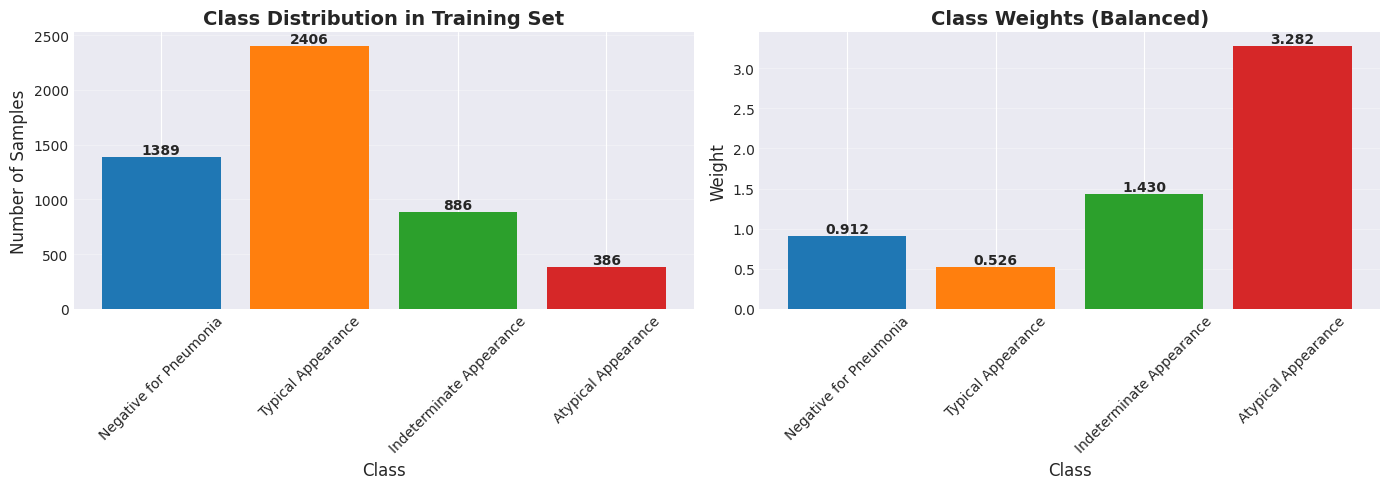


Note: Higher weights are assigned to minority classes to balance the loss function.
These weights will be used in the loss function during training.


In [37]:
# Calculate class weights to handle class imbalance
# Get class labels from training data
train_labels = train_df['study_label'].values

# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Create dictionary mapping class index to weight
class_weight_dict = dict(enumerate(class_weights))

print("=" * 60)
print("CLASS WEIGHTS CALCULATION")
print("=" * 60)
print("\nClass distribution in training set:")
class_counts = train_df['study_label'].value_counts().sort_index()
for class_idx in range(NUM_CLASSES):
    count = class_counts.get(class_idx, 0)
    weight = class_weight_dict[class_idx]
    label = CLASS_LABELS[class_idx]
    percentage = (count / len(train_df)) * 100
    print(f"Class {class_idx} ({label}):")
    print(f"Count: {count:4d} ({percentage:5.2f}%)")
    print(f"Weight: {weight:.4f}")

print("\n" + "=" * 60)
print("Class weights dictionary:")
print(class_weight_dict)
print("=" * 60)

# Visualize class distribution and weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_names = [CLASS_LABELS[i] for i in range(NUM_CLASSES)]
class_counts_list = [class_counts.get(i, 0) for i in range(NUM_CLASSES)]

axes[0].bar(class_names, class_counts_list, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts_list):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

# Class weights
class_weights_list = [class_weight_dict[i] for i in range(NUM_CLASSES)]
axes[1].bar(class_names, class_weights_list, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('Class Weights (Balanced)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Weight', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_weights_list):
    axes[1].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNote: Higher weights are assigned to minority classes to balance the loss function.")
print("These weights will be used in the loss function during training.")


## 5. Transfer Learning Model Creation

Create the transfer learning model by:
1. Loading a pre-trained base model (ResNet50)
2. Freezing the base model layers (Phase 1)
3. Adding a custom classification head
4. Configuring for fine-tuning (Phase 2)


In [38]:
def create_transfer_learning_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    freeze_base=True,
    fine_tune_layers=None
):
    """
    Create a transfer learning model with ResNet50 base and custom classification head
    
    Args:
        input_shape: Input image shape (height, width, channels)
        num_classes: Number of output classes
        freeze_base: Whether to freeze base model layers (True for Phase 1, False for Phase 2)
        fine_tune_layers: Number of layers to unfreeze for fine-tuning (None = auto)
    
    Returns:
        Compiled Keras model
    """
    # Load pre-trained ResNet50 base model
    print("Loading ResNet50 base model...")
    
    base_model = ResNet50(
        weights='imagenet',  # Use ImageNet pre-trained weights
        include_top=False,   # Don't include the classification head
        input_shape=input_shape
    )
    
    # Freeze or unfreeze base model layers
    if freeze_base:
        base_model.trainable = False
        print(f"  Base model frozen: {len([l for l in base_model.layers if not l.trainable])} layers frozen")
    else:
        # Unfreeze layers for fine-tuning
        base_model.trainable = True
        
        if fine_tune_layers is None:
            # Auto: unfreeze top layers (last ~20% of layers)
            num_layers = len(base_model.layers)
            fine_tune_from = int(num_layers * 0.8)  # Unfreeze last 20%
        else:
            fine_tune_from = len(base_model.layers) - fine_tune_layers
        
        # Freeze early layers, unfreeze later layers
        for layer in base_model.layers[:fine_tune_from]:
            layer.trainable = False
        for layer in base_model.layers[fine_tune_from:]:
            layer.trainable = True
        
        trainable_count = sum([1 for l in base_model.layers if l.trainable])
        print(f"  Fine-tuning enabled: {trainable_count} layers trainable (from layer {fine_tune_from})")
    
    # Create the model
    inputs = Input(shape=input_shape)
    
    # Pass input through base model
    x = base_model(inputs, training=False)  # Set training=False for batch norm layers
    
    # Global Average Pooling: (batch, H, W, C) -> (batch, C)
    x = GlobalAveragePooling2D()(x)
    
    # Custom classification head
    # First dense layer
    x = Dense(512, activation='relu', name='feature_extraction')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    # Second dense layer
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    # Classification output
    outputs = Dense(num_classes, activation='softmax', name='classification')(x)
    
    # Create model
    model = Model(inputs=inputs, outputs=outputs, name='resnet50_transfer_learning')
    
    return model

# Create the model for Phase 1 (frozen base)
print("=" * 60)
print("CREATING TRANSFER LEARNING MODEL - PHASE 1")
print("=" * 60)
print(f"Base model: ResNet50")
print(f"Input shape: ({IMG_SIZE}, {IMG_SIZE}, 3)")
print(f"Number of classes: {NUM_CLASSES}")

model_phase1 = create_transfer_learning_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    freeze_base=True,  # Freeze base model in Phase 1
    fine_tune_layers=FINE_TUNE_LAYERS
)

print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
model_phase1.summary()

# Count trainable vs non-trainable parameters
trainable_params = sum([tf.size(w).numpy() for w in model_phase1.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model_phase1.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print("\n" + "=" * 60)
print("PARAMETER COUNT")
print("=" * 60)
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"Non-trainable parameters: {non_trainable_params:,} ({non_trainable_params/total_params*100:.2f}%)")
print(f"Total parameters: {total_params:,}")
print("=" * 60)


CREATING TRANSFER LEARNING MODEL - PHASE 1
Base model: ResNet50
Input shape: (256, 256, 3)
Number of classes: 4
Loading ResNet50 base model...
  Base model frozen: 175 layers frozen

MODEL SUMMARY


Model: "resnet50_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extraction (Dense)      │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,772,228 (94.50 MB)

 Trainable params: 1,182,980 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)


PARAMETER COUNT
Trainable parameters: 1,182,980 (4.78%)
Non-trainable parameters: 23,589,248 (95.22%)
Total parameters: 24,772,228


## 6. Phase 1: Feature Extraction Training

Train only the custom classification head while keeping the base model frozen. This phase learns to use the pre-trained features for our specific task.


In [39]:
# Compile model for Phase 1 training
model_phase1.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE_PHASE1),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("=" * 60)
print("PHASE 1: MODEL COMPILATION")
print("=" * 60)
print(f"Optimizer: Adam")
print(f"Learning rate: {LEARNING_RATE_PHASE1}")
print(f"Loss: Sparse Categorical Crossentropy (with class weights)")
print(f"Metrics: Accuracy")
print("=" * 60)


PHASE 1: MODEL COMPILATION
Optimizer: Adam
Learning rate: 0.001
Loss: Sparse Categorical Crossentropy (with class weights)
Metrics: Accuracy


In [40]:
# Setup callbacks for Phase 1 training
callbacks_phase1 = [
    # Save best model based on validation accuracy
    ModelCheckpoint(
        filepath=str(MODEL_WEIGHTS_PATH_PHASE1),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Log training history
    CSVLogger(
        filename=str(MODEL_DIR_TRANSFER / 'phase1_training_history.csv'),
        append=False
    ),
    
    # TensorBoard logging
    TensorBoard(
        log_dir=str(MODEL_DIR_TRANSFER / 'logs' / 'phase1'),
        histogram_freq=1
    )
]

print("Callbacks configured for Phase 1:")
print("  - ModelCheckpoint: Save best model weights")
print("  - EarlyStopping: Stop if no improvement for 10 epochs")
print("  - ReduceLROnPlateau: Reduce LR when validation plateaus")
print("  - CSVLogger: Save training history")
print("  - TensorBoard: Log training metrics")


Callbacks configured for Phase 1:
  - ModelCheckpoint: Save best model weights
  - EarlyStopping: Stop if no improvement for 10 epochs
  - ReduceLROnPlateau: Reduce LR when validation plateaus
  - CSVLogger: Save training history
  - TensorBoard: Log training metrics


In [41]:
# Phase 1: Feature Extraction Training
print("=" * 60)
print("PHASE 1: FEATURE EXTRACTION TRAINING")
print("=" * 60)
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS_PHASE1}")
print(f"Learning rate: {LEARNING_RATE_PHASE1}")
print(f"Base model: ResNet50 (FROZEN)")
print(f"Class weights: Enabled")
print("=" * 60)

# Verify GPU is available
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"\nGPU detected: {gpus[0].name}")
    print("Training will use GPU acceleration")
else:
    print("\nWARNING: No GPU detected - training will be slower on CPU")

print("\nStarting Phase 1 training...")
print("This phase trains only the custom classification head.\n")

# Train the model with class weights
history_phase1 = model_phase1.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    callbacks=callbacks_phase1,
    class_weight=class_weight_dict,  # Apply class weights to handle imbalance
    verbose=1
)

print("\n" + "=" * 60)
print("PHASE 1 TRAINING COMPLETED!")
print("=" * 60)


PHASE 1: FEATURE EXTRACTION TRAINING
Training samples: 5067
Validation samples: 1267
Batch size: 32
Epochs: 30
Learning rate: 0.001
Base model: ResNet50 (FROZEN)
Class weights: Enabled

GPU detected: /physical_device:GPU:0
Training will use GPU acceleration

Starting Phase 1 training...
This phase trains only the custom classification head.

Epoch 1/30
124/159 ━━━━━━━━━━━━━━━━━━━━ 11s 336ms/step - accuracy: 0.3669 - loss: 1.9504

2025-12-21 17:13:39.392966: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion', 16 bytes spill stores, 16 bytes spill loads



159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.3726 - loss: 1.9078
Epoch 1: val_accuracy improved from None to 0.57932, saving model to models/transfer_learning/resnet50_phase1.weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 87s 463ms/step - accuracy: 0.3925 - loss: 1.7242 - val_accuracy: 0.5793 - val_loss: 1.2273 - learning_rate: 0.0010
Epoch 2/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.4310 - loss: 1.4591
Epoch 2: val_accuracy did not improve from 0.57932
159/159 ━━━━━━━━━━━━━━━━━━━━ 58s 360ms/step - accuracy: 0.4217 - loss: 1.4537 - val_accuracy: 0.4609 - val_loss: 1.2520 - learning_rate: 0.0010
Epoch 3/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4465 - loss: 1.3420
Epoch 3: val_accuracy did not improve from 0.57932
159/159 ━━━━━━━━━━━━━━━━━━━━ 57s 358ms/step - accuracy: 0.4490 - loss: 1.3326 - val_accuracy: 0.4601 - val_loss: 1.2078 - learning_rate: 0.0010
Epoch 4/30
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.4614 - loss: 1.3068
Epoc

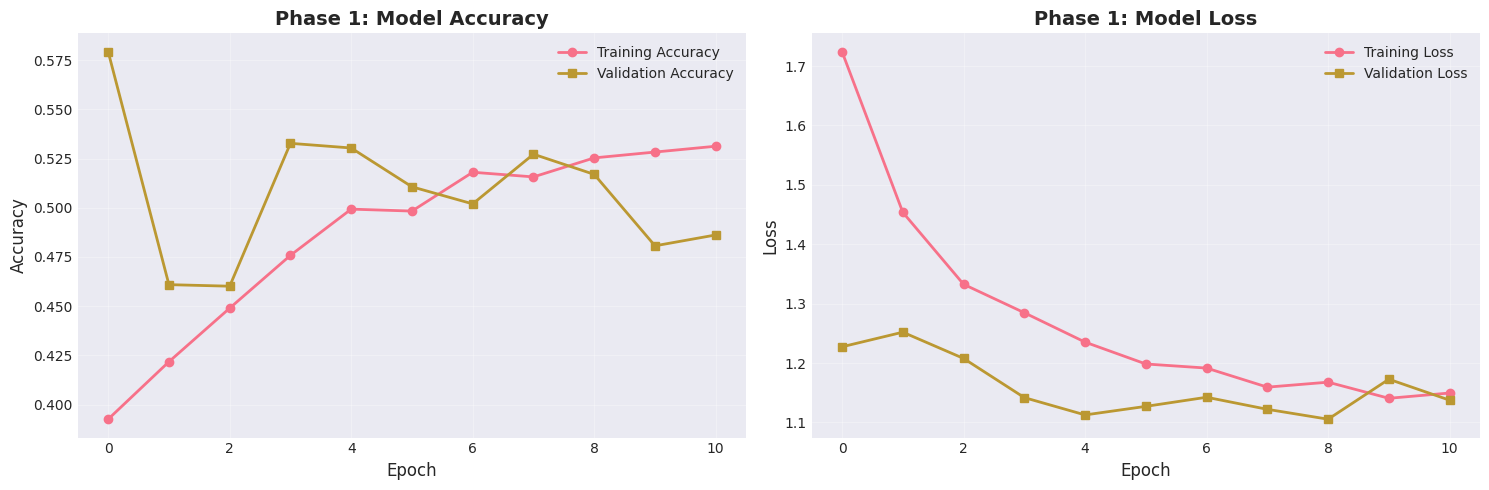


PHASE 1 FINAL METRICS
Training Accuracy: 0.5313
Validation Accuracy: 0.4862
Training Loss: 1.1495
Validation Loss: 1.1375

Best Validation Accuracy: 0.5793 (Epoch 1)


In [42]:
# Visualize Phase 1 training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history_phase1.history['accuracy'], label='Training Accuracy', marker='o', linewidth=2)
axes[0].plot(history_phase1.history['val_accuracy'], label='Validation Accuracy', marker='s', linewidth=2)
axes[0].set_title('Phase 1: Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history_phase1.history['loss'], label='Training Loss', marker='o', linewidth=2)
axes[1].plot(history_phase1.history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
axes[1].set_title('Phase 1: Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\n" + "=" * 60)
print("PHASE 1 FINAL METRICS")
print("=" * 60)
print(f"Training Accuracy: {history_phase1.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_phase1.history['val_accuracy'][-1]:.4f}")
print(f"Training Loss: {history_phase1.history['loss'][-1]:.4f}")
print(f"Validation Loss: {history_phase1.history['val_loss'][-1]:.4f}")

# Find best validation accuracy
best_val_acc = max(history_phase1.history['val_accuracy'])
best_epoch = history_phase1.history['val_accuracy'].index(best_val_acc) + 1
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
print("=" * 60)


## 7. Phase 2: Fine-tuning

Unfreeze the top layers of the base model and continue training with a lower learning rate. This allows the model to adapt the pre-trained features to our specific task.


In [43]:
# Create Phase 2 model (unfreeze top layers)
print("=" * 60)
print("CREATING TRANSFER LEARNING MODEL - PHASE 2")
print("=" * 60)
print(f"Base model: ResNet50")
print(f"Unfreezing top layers for fine-tuning...")

model_phase2 = create_transfer_learning_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    freeze_base=False,  # Unfreeze base model
    fine_tune_layers=FINE_TUNE_LAYERS  # None = auto (unfreeze last 20%)
)

# Load Phase 1 best weights into Phase 2 model
# This ensures we start fine-tuning from the best Phase 1 weights
print("\n" + "=" * 60)
print("LOADING PHASE 1 BEST WEIGHTS")
print("=" * 60)
model_phase2.load_weights(str(MODEL_WEIGHTS_PATH_PHASE1))
print(f"Loaded weights from: {MODEL_WEIGHTS_PATH_PHASE1}")

# Count trainable parameters
trainable_params = sum([tf.size(w).numpy() for w in model_phase2.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model_phase2.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print("\n" + "=" * 60)
print("PHASE 2 PARAMETER COUNT")
print("=" * 60)
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"Non-trainable parameters: {non_trainable_params:,} ({non_trainable_params/total_params*100:.2f}%)")
print(f"Total parameters: {total_params:,}")
print("=" * 60)


CREATING TRANSFER LEARNING MODEL - PHASE 2
Base model: ResNet50
Unfreezing top layers for fine-tuning...
Loading ResNet50 base model...
  Fine-tuning enabled: 35 layers trainable (from layer 140)

LOADING PHASE 1 BEST WEIGHTS
Loaded weights from: models/transfer_learning/resnet50_phase1.weights.h5

PHASE 2 PARAMETER COUNT
Trainable parameters: 16,161,028 (65.24%)
Non-trainable parameters: 8,611,200 (34.76%)
Total parameters: 24,772,228


In [44]:
# Compile model for Phase 2 training with lower learning rate
model_phase2.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE_PHASE2),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

print("=" * 60)
print("PHASE 2: MODEL COMPILATION")
print("=" * 60)
print(f"Optimizer: Adam")
print(f"Learning rate: {LEARNING_RATE_PHASE2} (lower than Phase 1)")
print(f"Loss: Sparse Categorical Crossentropy (with class weights)")
print(f"Metrics: Accuracy")
print("=" * 60)


PHASE 2: MODEL COMPILATION
Optimizer: Adam
Learning rate: 1e-05 (lower than Phase 1)
Loss: Sparse Categorical Crossentropy (with class weights)
Metrics: Accuracy


In [45]:
# Setup callbacks for Phase 2 training
callbacks_phase2 = [
    # Save best model based on validation accuracy
    ModelCheckpoint(
        filepath=str(MODEL_WEIGHTS_PATH_PHASE2),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-8,
        verbose=1
    ),
    
    # Log training history
    CSVLogger(
        filename=str(MODEL_DIR_TRANSFER / 'phase2_training_history.csv'),
        append=False
    ),
    
    # TensorBoard logging
    TensorBoard(
        log_dir=str(MODEL_DIR_TRANSFER / 'logs' / 'phase2'),
        histogram_freq=1
    )
]

print("Callbacks configured for Phase 2:")
print("  - ModelCheckpoint: Save best model weights")
print("  - EarlyStopping: Stop if no improvement for 10 epochs")
print("  - ReduceLROnPlateau: Reduce LR when validation plateaus")
print("  - CSVLogger: Save training history")
print("  - TensorBoard: Log training metrics")


Callbacks configured for Phase 2:
  - ModelCheckpoint: Save best model weights
  - EarlyStopping: Stop if no improvement for 10 epochs
  - ReduceLROnPlateau: Reduce LR when validation plateaus
  - CSVLogger: Save training history
  - TensorBoard: Log training metrics


In [46]:
# Phase 2: Fine-tuning Training
print("=" * 60)
print("PHASE 2: FINE-TUNING TRAINING")
print("=" * 60)
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS_PHASE2}")
print(f"Learning rate: {LEARNING_RATE_PHASE2} (10x lower than Phase 1)")
print(f"Base model: ResNet50 (TOP LAYERS UNFROZEN)")
print(f"Class weights: Enabled")
print("=" * 60)

# Verify GPU is available
gpus = tf.config.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"\nGPU detected: {gpus[0].name}")
    print("Training will use GPU acceleration")
else:
    print("\nWARNING: No GPU detected - training will be slower on CPU")

print("\nStarting Phase 2 fine-tuning...")
print("This phase fine-tunes the top layers of the base model.\n")

# Train the model with class weights
history_phase2 = model_phase2.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    class_weight=class_weight_dict,  # Apply class weights to handle imbalance
    verbose=1
)

print("\n" + "=" * 60)
print("PHASE 2 TRAINING COMPLETED!")
print("=" * 60)


PHASE 2: FINE-TUNING TRAINING
Training samples: 5067
Validation samples: 1267
Batch size: 32
Epochs: 20
Learning rate: 1e-05 (10x lower than Phase 1)
Base model: ResNet50 (TOP LAYERS UNFROZEN)
Class weights: Enabled

GPU detected: /physical_device:GPU:0
Training will use GPU acceleration

Starting Phase 2 fine-tuning...
This phase fine-tunes the top layers of the base model.

Epoch 1/20
152/159 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - accuracy: 0.4012 - loss: 1.5279

2025-12-21 17:25:05.344782: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion', 16 bytes spill stores, 16 bytes spill loads



159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.4013 - loss: 1.5280
Epoch 1: val_accuracy improved from None to 0.49092, saving model to models/transfer_learning/resnet50_phase2.weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 102s 499ms/step - accuracy: 0.4044 - loss: 1.5252 - val_accuracy: 0.4909 - val_loss: 1.2460 - learning_rate: 1.0000e-05
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.4263 - loss: 1.4533
Epoch 2: val_accuracy did not improve from 0.49092
159/159 ━━━━━━━━━━━━━━━━━━━━ 60s 375ms/step - accuracy: 0.4318 - loss: 1.4506 - val_accuracy: 0.4720 - val_loss: 1.2328 - learning_rate: 1.0000e-05
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.4466 - loss: 1.3866
Epoch 3: val_accuracy did not improve from 0.49092
159/159 ━━━━━━━━━━━━━━━━━━━━ 58s 362ms/step - accuracy: 0.4474 - loss: 1.3978 - val_accuracy: 0.4846 - val_loss: 1.1962 - learning_rate: 1.0000e-05
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.4515 - loss

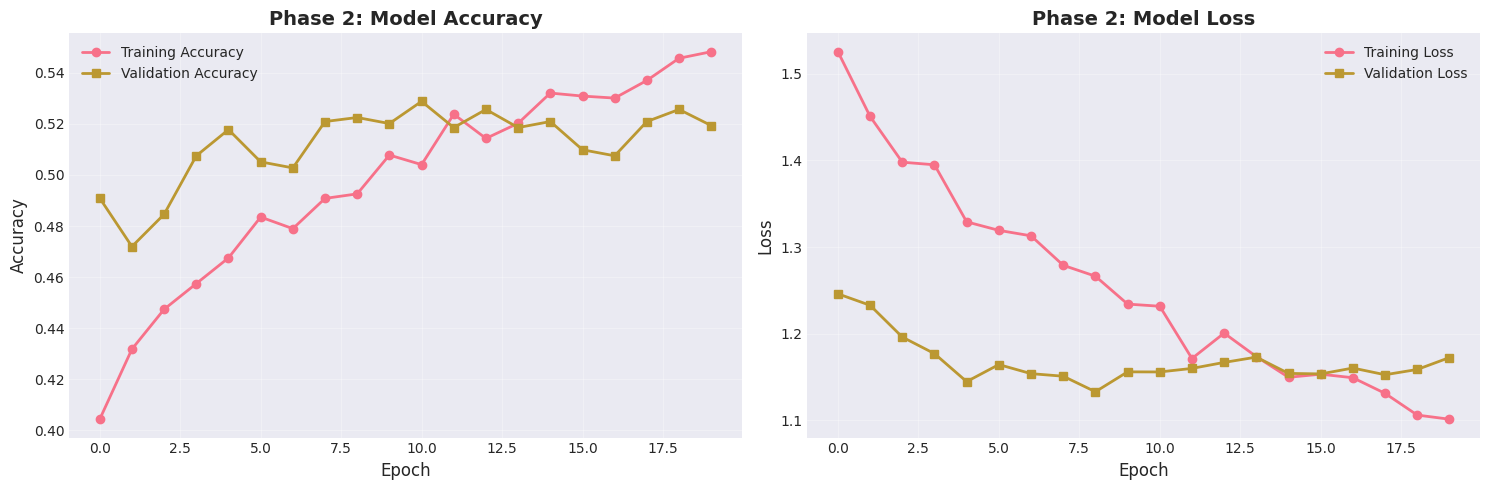


PHASE 2 FINAL METRICS
Training Accuracy: 0.5483
Validation Accuracy: 0.5193
Training Loss: 1.1015
Validation Loss: 1.1726

Best Validation Accuracy: 0.5288 (Epoch 11)

Phase 1 Best Accuracy: 0.5793
Improvement: -0.0505 (-8.72%)


In [47]:
# Visualize Phase 2 training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history_phase2.history['accuracy'], label='Training Accuracy', marker='o', linewidth=2)
axes[0].plot(history_phase2.history['val_accuracy'], label='Validation Accuracy', marker='s', linewidth=2)
axes[0].set_title('Phase 2: Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history_phase2.history['loss'], label='Training Loss', marker='o', linewidth=2)
axes[1].plot(history_phase2.history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
axes[1].set_title('Phase 2: Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\n" + "=" * 60)
print("PHASE 2 FINAL METRICS")
print("=" * 60)
print(f"Training Accuracy: {history_phase2.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_phase2.history['val_accuracy'][-1]:.4f}")
print(f"Training Loss: {history_phase2.history['loss'][-1]:.4f}")
print(f"Validation Loss: {history_phase2.history['val_loss'][-1]:.4f}")

# Find best validation accuracy
best_val_acc = max(history_phase2.history['val_accuracy'])
best_epoch = history_phase2.history['val_accuracy'].index(best_val_acc) + 1
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")

# Compare with Phase 1
phase1_best = max(history_phase1.history['val_accuracy'])
improvement = best_val_acc - phase1_best
print(f"\nPhase 1 Best Accuracy: {phase1_best:.4f}")
print(f"Improvement: {improvement:+.4f} ({improvement/phase1_best*100:+.2f}%)")
print("=" * 60)


## 8. Model Evaluation

Evaluate the fine-tuned model with detailed metrics, confusion matrix, and per-class performance analysis.


In [48]:
# Load best model weights from Phase 2
print("=" * 60)
print("LOADING BEST MODEL WEIGHTS")
print("=" * 60)
model_phase2.load_weights(str(MODEL_WEIGHTS_PATH_PHASE2))
print(f"Loaded weights from: {MODEL_WEIGHTS_PATH_PHASE2}")

# Predict on validation set
print("\n" + "=" * 60)
print("EVALUATING ON VALIDATION SET")
print("=" * 60)
print("Generating predictions...")

val_predictions = model_phase2.predict(val_generator, verbose=1)
val_predicted_classes = np.argmax(val_predictions, axis=1)
val_true_classes = val_df['study_label'].values

print(f"\nPredictions generated for {len(val_true_classes)} validation samples")


LOADING BEST MODEL WEIGHTS
Loaded weights from: models/transfer_learning/resnet50_phase2.weights.h5

EVALUATING ON VALIDATION SET
Generating predictions...
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 381ms/step

Predictions generated for 1267 validation samples


In [49]:
# Calculate overall metrics
accuracy = accuracy_score(val_true_classes, val_predicted_classes)
precision = precision_score(val_true_classes, val_predicted_classes, average='weighted')
recall = recall_score(val_true_classes, val_predicted_classes, average='weighted')
f1 = f1_score(val_true_classes, val_predicted_classes, average='weighted')

# Calculate macro-averaged metrics (treats all classes equally)
precision_macro = precision_score(val_true_classes, val_predicted_classes, average='macro')
recall_macro = recall_score(val_true_classes, val_predicted_classes, average='macro')
f1_macro = f1_score(val_true_classes, val_predicted_classes, average='macro')

print("=" * 60)
print("OVERALL VALIDATION METRICS")
print("=" * 60)
print(f"Weighted Average (accounts for class imbalance):")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"\nMacro Average (treats all classes equally):")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall:    {recall_macro:.4f}")
print(f"  F1-Score:  {f1_macro:.4f}")
print("=" * 60)


OVERALL VALIDATION METRICS
Weighted Average (accounts for class imbalance):
  Accuracy:  0.5288
  Precision: 0.5993
  Recall:    0.5288
  F1-Score:  0.5407

Macro Average (treats all classes equally):
  Precision: 0.4471
  Recall:    0.4708
  F1-Score:  0.4333


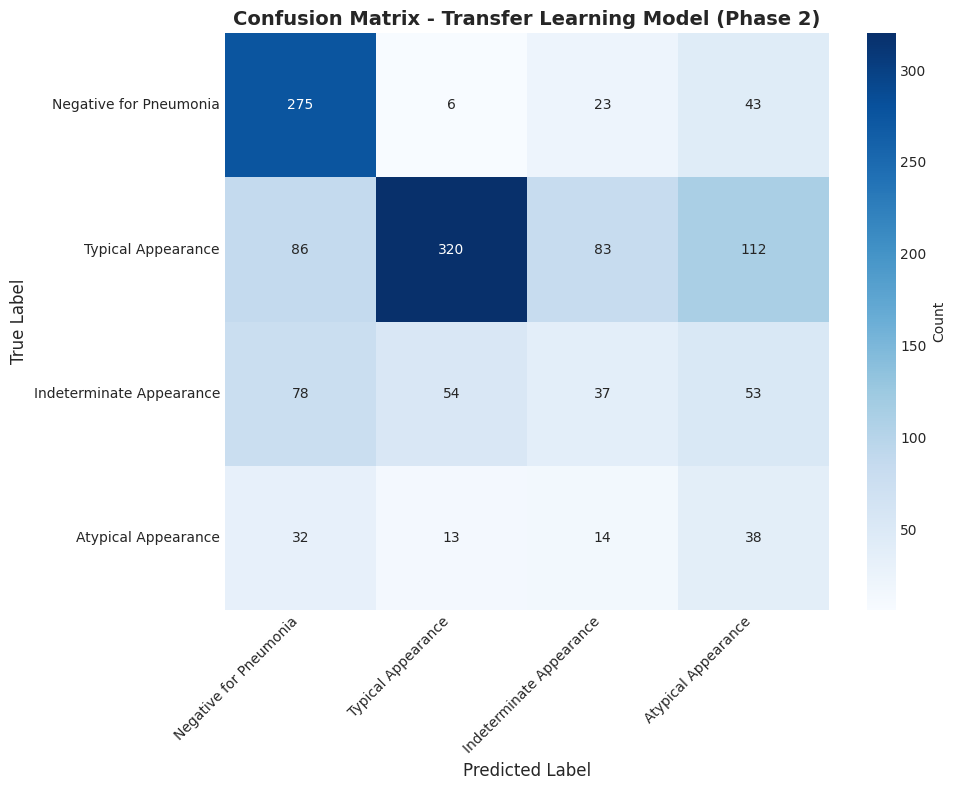


PER-CLASS METRICS FROM CONFUSION MATRIX

Negative for Pneumonia:
  Precision: 0.5839
  Recall:    0.7925
  F1-Score:  0.6724
  Support:   347

Typical Appearance:
  Precision: 0.8142
  Recall:    0.5324
  F1-Score:  0.6439
  Support:   601

Indeterminate Appearance:
  Precision: 0.2357
  Recall:    0.1667
  F1-Score:  0.1953
  Support:   222

Atypical Appearance:
  Precision: 0.1545
  Recall:    0.3918
  F1-Score:  0.2216
  Support:   97


In [50]:
# Confusion Matrix
cm = confusion_matrix(val_true_classes, val_predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Transfer Learning Model (Phase 2)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class metrics from confusion matrix
print("\n" + "=" * 60)
print("PER-CLASS METRICS FROM CONFUSION MATRIX")
print("=" * 60)
for i in range(NUM_CLASSES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    
    precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class) if (precision_class + recall_class) > 0 else 0
    support = tp + fn
    
    print(f"\n{CLASS_LABELS[i]}:")
    print(f"  Precision: {precision_class:.4f}")
    print(f"  Recall:    {recall_class:.4f}")
    print(f"  F1-Score:  {f1_class:.4f}")
    print(f"  Support:   {support}")
print("=" * 60)


In [51]:
# Classification Report
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    val_true_classes, 
    val_predicted_classes, 
    target_names=[CLASS_LABELS[i] for i in range(NUM_CLASSES)],
    digits=4
))
print("=" * 60)



DETAILED CLASSIFICATION REPORT
                          precision    recall  f1-score   support

  Negative for Pneumonia     0.5839    0.7925    0.6724       347
      Typical Appearance     0.8142    0.5324    0.6439       601
Indeterminate Appearance     0.2357    0.1667    0.1953       222
     Atypical Appearance     0.1545    0.3918    0.2216        97

                accuracy                         0.5288      1267
               macro avg     0.4471    0.4708    0.4333      1267
            weighted avg     0.5993    0.5288    0.5407      1267



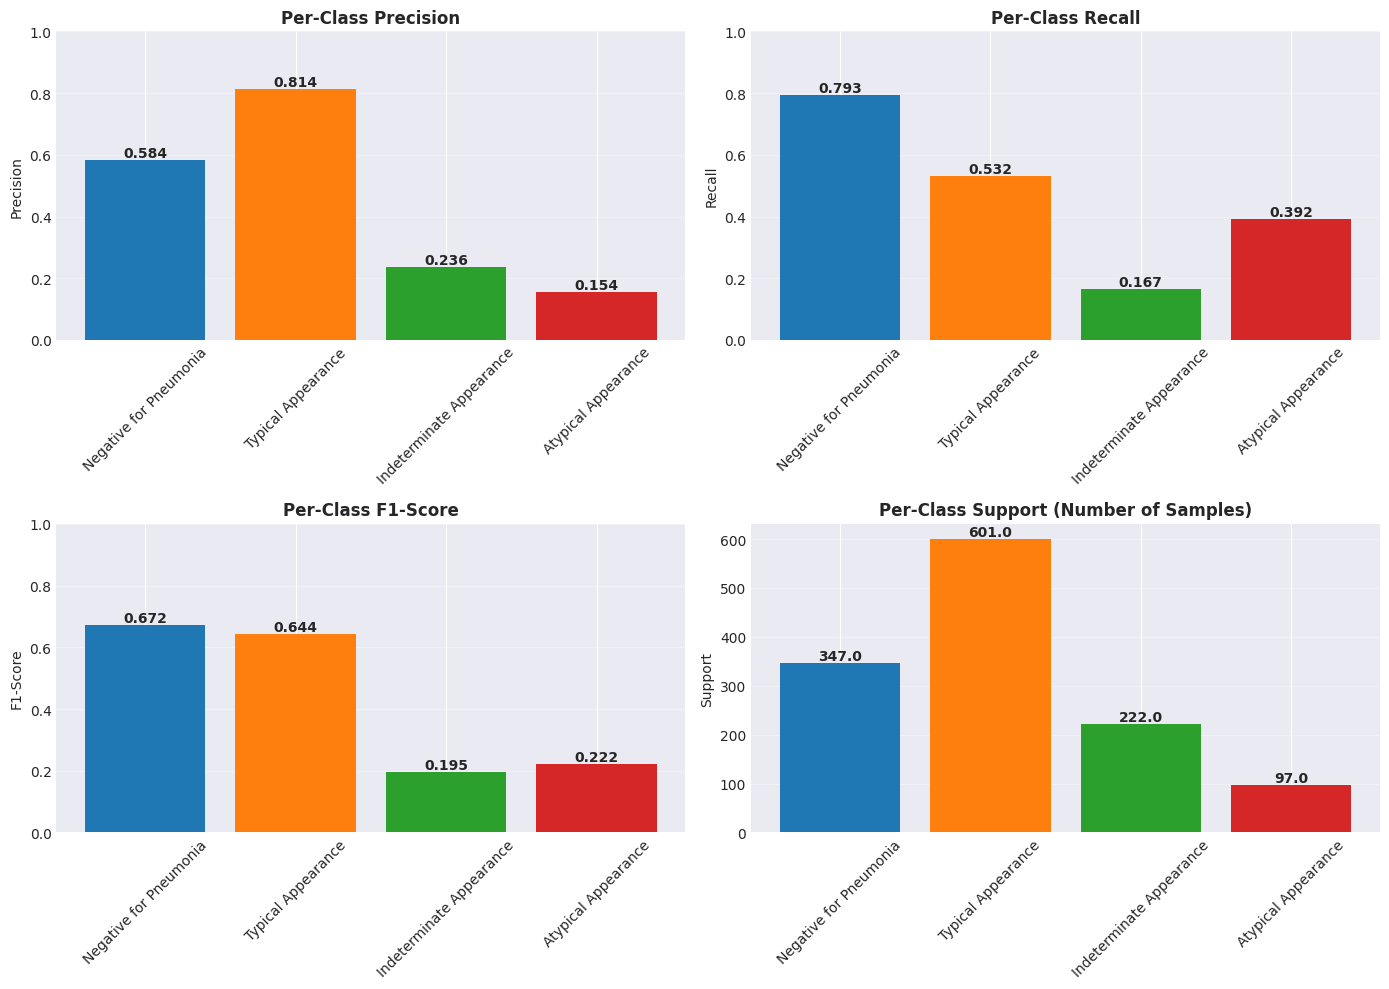


Note: These visualizations show how well the model performs on each individual class.
Higher values indicate better performance for that class.


In [52]:
# Visualize per-class performance
class_names = [CLASS_LABELS[i] for i in range(NUM_CLASSES)]
per_class_metrics = classification_report(
    val_true_classes, 
    val_predicted_classes, 
    target_names=class_names,
    output_dict=True
)

# Extract metrics for each class
precisions = [per_class_metrics[class_name]['precision'] for class_name in class_names]
recalls = [per_class_metrics[class_name]['recall'] for class_name in class_names]
f1_scores = [per_class_metrics[class_name]['f1-score'] for class_name in class_names]
supports = [per_class_metrics[class_name]['support'] for class_name in class_names]

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precision
axes[0, 0].bar(class_names, precisions, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0, 0].set_title('Per-Class Precision', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Precision', fontsize=10)
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(precisions):
    axes[0, 0].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Recall
axes[0, 1].bar(class_names, recalls, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0, 1].set_title('Per-Class Recall', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Recall', fontsize=10)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(recalls):
    axes[0, 1].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# F1-Score
axes[1, 0].bar(class_names, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1, 0].set_title('Per-Class F1-Score', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('F1-Score', fontsize=10)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_scores):
    axes[1, 0].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Support (number of samples)
axes[1, 1].bar(class_names, supports, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1, 1].set_title('Per-Class Support (Number of Samples)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Support', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(supports):
    axes[1, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNote: These visualizations show how well the model performs on each individual class.")
print("Higher values indicate better performance for that class.")


## 9. Comparison with Custom CNN Baseline

Compare the transfer learning model performance with the custom CNN baseline model to evaluate the benefits of using pre-trained models.


In [53]:
# Import ModelComparator for comprehensive model comparison
from compare_models import ModelComparator

# Custom CNN baseline metrics (from Covid19_Image_Modeling_1.ipynb)
# These values are from the custom CNN model evaluation
# Update these values if you have different results from your custom CNN training

custom_cnn_metrics = {
    'accuracy': 0.6093,  # Update with your custom CNN validation accuracy
    'precision_weighted': 0.4581,
    'recall_weighted': 0.6093,
    'f1_weighted': 0.5183,
    'precision_macro': 0.31,  # Approximate from classification report
    'recall_macro': 0.39,
    'f1_macro': 0.34,
    'per_class': {
        'Negative for Pneumonia': {'precision': 0.63, 'recall': 0.64, 'f1': 0.64},
        'Typical Appearance': {'precision': 0.60, 'recall': 0.91, 'f1': 0.72},
        'Indeterminate Appearance': {'precision': 0.00, 'recall': 0.00, 'f1': 0.00},
        'Atypical Appearance': {'precision': 0.00, 'recall': 0.00, 'f1': 0.00}
    }
}

# Transfer Learning metrics (from current evaluation)
transfer_learning_metrics = {
    'accuracy': accuracy,
    'precision_weighted': precision,
    'recall_weighted': recall,
    'f1_weighted': f1,
    'precision_macro': precision_macro,
    'recall_macro': recall_macro,
    'f1_macro': f1_macro,
    'per_class': {}
}

# Extract per-class metrics for transfer learning
for i, class_name in enumerate(class_names):
    transfer_learning_metrics['per_class'][class_name] = {
        'precision': precisions[i],
        'recall': recalls[i],
        'f1': f1_scores[i]
    }

# Create ModelComparator instance
comparator = ModelComparator(
    custom_cnn_metrics=custom_cnn_metrics,
    transfer_learning_metrics=transfer_learning_metrics,
    class_labels=CLASS_LABELS,
    output_dir=Path('comparison_results')
)

print("=" * 60)
print("MODEL COMPARISON: TRANSFER LEARNING vs CUSTOM CNN")
print("=" * 60)
print("Using ModelComparator from compare_models.py")
print("=" * 60)


MODEL COMPARISON: TRANSFER LEARNING vs CUSTOM CNN
Using ModelComparator from compare_models.py


OVERALL METRICS COMPARISON
              Metric  Custom CNN  Transfer Learning  Improvement  Improvement %
            Accuracy      0.6093           0.528808    -0.080492         -13.21
Precision (Weighted)      0.4581           0.599264     0.141164          30.82
   Recall (Weighted)      0.6093           0.528808    -0.080492         -13.21
 F1-Score (Weighted)      0.5183           0.540736     0.022436           4.33
   Precision (Macro)      0.3100           0.447063     0.137063          44.21
      Recall (Macro)      0.3900           0.470843     0.080843          20.73
    F1-Score (Macro)      0.3400           0.433265     0.093265          27.43

✓ Comparison saved to: comparison_results/overall_metrics_comparison.csv
✓ Figure saved to: comparison_results/overall_metrics_comparison.png


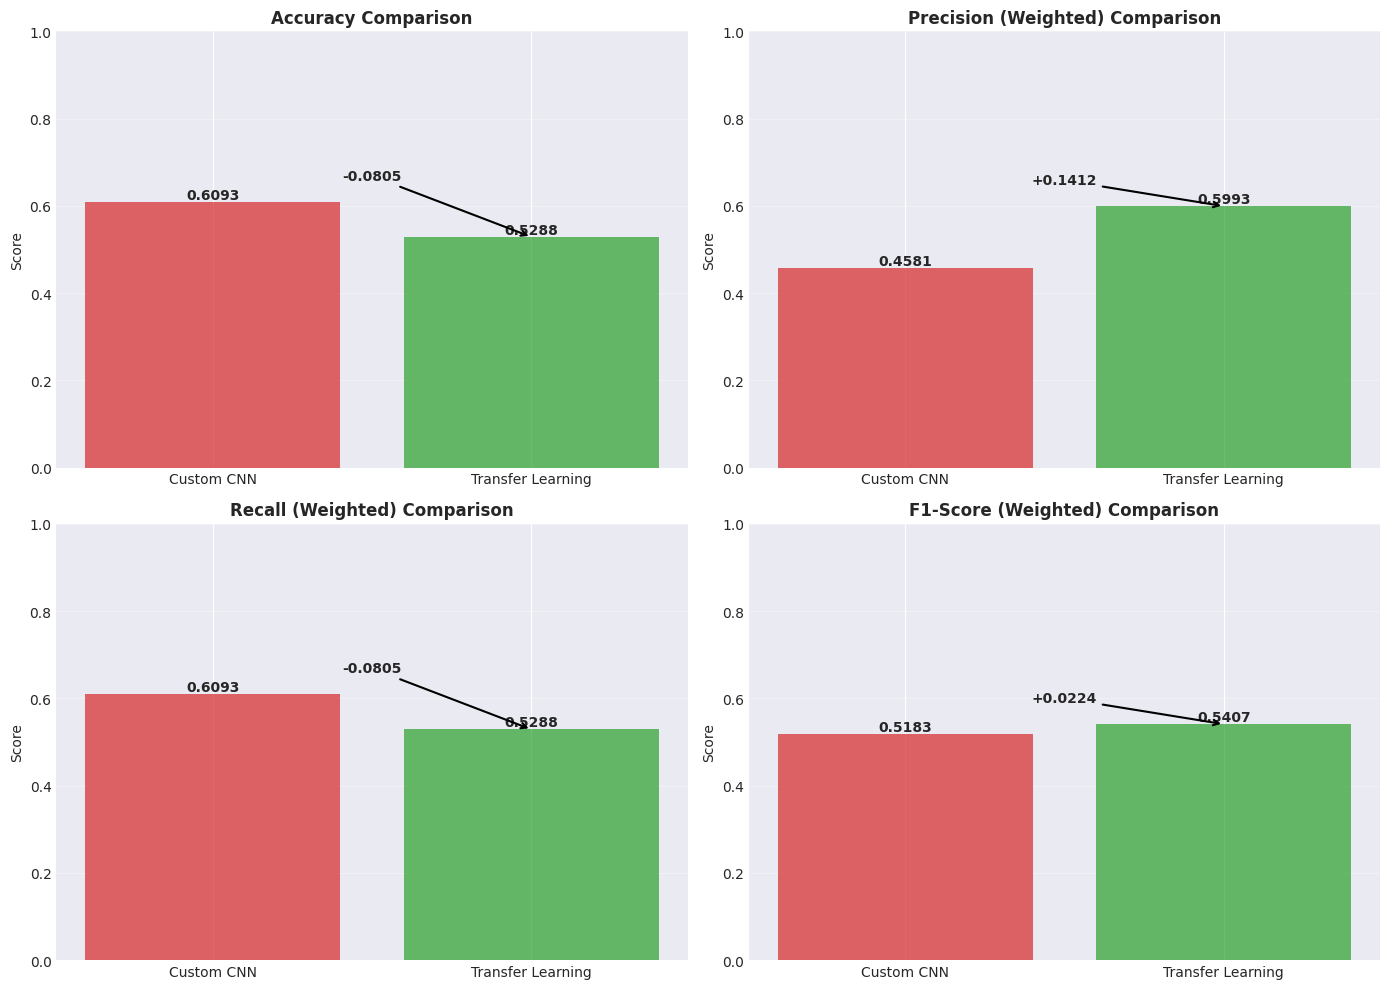

In [54]:
# Compare overall metrics using ModelComparator
comparison_df = comparator.compare_overall_metrics()
comparator.visualize_overall_metrics(comparison_df)


PER-CLASS METRICS COMPARISON
                   Class  CNN Precision  TL Precision  Precision Δ  CNN Recall  TL Recall  Recall Δ  CNN F1    TL F1      F1 Δ
  Negative for Pneumonia           0.63      0.583864    -0.046136        0.64   0.792507  0.152507    0.64 0.672372  0.032372
      Typical Appearance           0.60      0.814249     0.214249        0.91   0.532446 -0.377554    0.72 0.643863 -0.076137
Indeterminate Appearance           0.00      0.235669     0.235669        0.00   0.166667  0.166667    0.00 0.195251  0.195251
     Atypical Appearance           0.00      0.154472     0.154472        0.00   0.391753  0.391753    0.00 0.221574  0.221574

✓ Per-class comparison saved to: comparison_results/per_class_metrics_comparison.csv
✓ Figure saved to: comparison_results/per_class_metrics_comparison.png


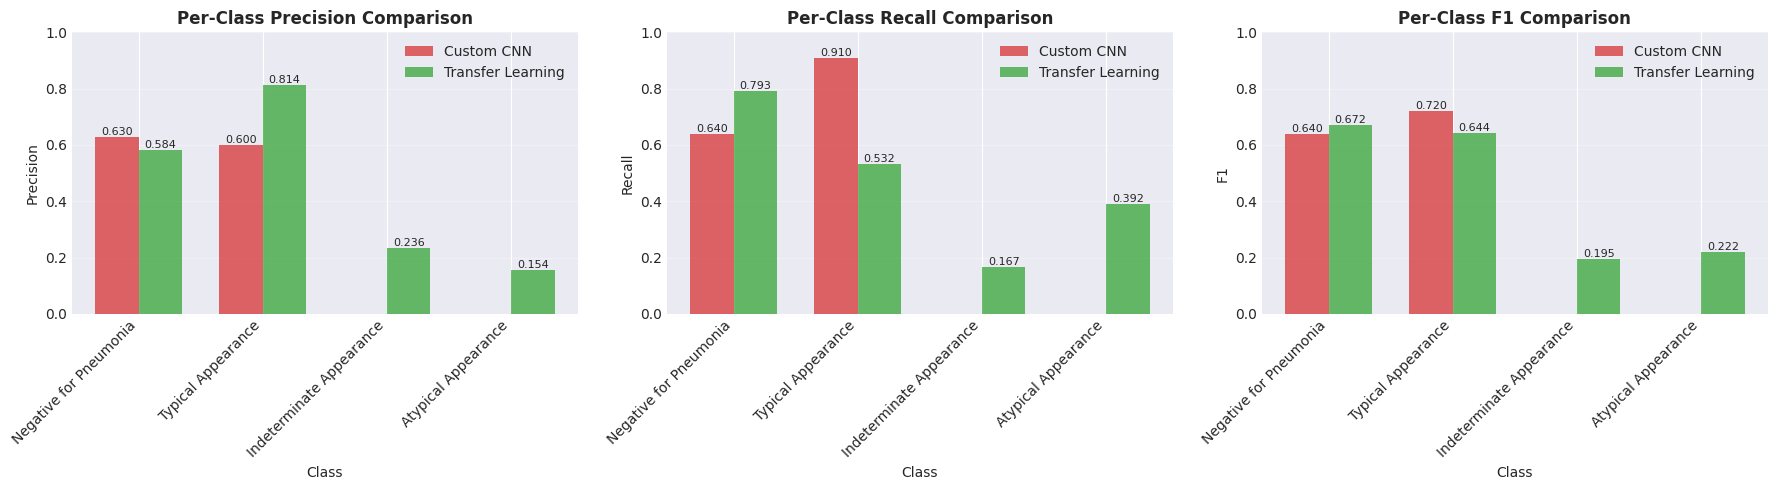

In [55]:
# Compare per-class metrics using ModelComparator
per_class_df = comparator.compare_per_class_metrics()
comparator.visualize_per_class_metrics(per_class_df)

In [56]:
# Generate summary report using ModelComparator
comparator.generate_summary_report(comparison_df, per_class_df)

print("\n" + "=" * 60)
print("COMPARISON COMPLETE!")
print(f"All comparison results saved to: {comparator.output_dir}")
print("=" * 60)


SUMMARY OF IMPROVEMENTS

Overall Metrics:
  Accuracy improvement: -0.0805 (-13.21%)
  Weighted F1 improvement: +0.0224 (+4.33%)
  Macro F1 improvement: +0.0933 (+27.43%)

Per-Class Improvements:

  Negative for Pneumonia:
    Precision: -0.0461
    Recall:    +0.1525
    F1-Score:  +0.0324

  Typical Appearance:
    Precision: +0.2142
    Recall:    -0.3776
    F1-Score:  -0.0761

  Indeterminate Appearance:
    Precision: +0.2357
    Recall:    +0.1667
    F1-Score:  +0.1953

  Atypical Appearance:
    Precision: +0.1545
    Recall:    +0.3918
    F1-Score:  +0.2216

KEY FINDINGS

✓ Transfer learning improved performance on minority classes:
  - Indeterminate Appearance: Improved from 0.00 to 0.1953 F1-Score
  - Atypical Appearance: Improved from 0.00 to 0.2216 F1-Score

⚠ Overall accuracy decreased by 0.0805

✓ Summary saved to: comparison_results/comparison_summary.txt

COMPARISON COMPLETE!
All comparison results saved to: comparison_results


## 10. Model Serialization

Save the complete transfer learning model package using ModelSerializer, including model architecture, weights, hyperparameters, preprocessing functions, and training history.


In [57]:
# Import model serialization module
from model_serialization import ModelSerializer

# Create serializer instance
serializer = ModelSerializer()

# Prepare augmentation configuration
augmentation_config = {
    'rotation_range': 15,
    'width_shift_range': 0.1,
    'height_shift_range': 0.1,
    'shear_range': 0.1,
    'zoom_range': 0.1,
    'horizontal_flip': True,
    'fill_mode': 'nearest',
}

# Prepare validation metrics
val_metrics = {
    'accuracy': accuracy,
    'precision_weighted': precision,
    'recall_weighted': recall,
    'f1_weighted': f1,
    'precision_macro': precision_macro,
    'recall_macro': recall_macro,
    'f1_macro': f1_macro,
    'loss': history_phase2.history['val_loss'][-1] if 'history_phase2' in locals() else None
}

# Combine training history from both phases
# Handle different lengths by padding shorter arrays with NaN
combined_training_history = {}
phase1_length = 0
phase2_length = 0

if 'history_phase1' in locals() and hasattr(history_phase1, 'history'):
    for key, values in history_phase1.history.items():
        combined_training_history[f'phase1_{key}'] = values
        phase1_length = len(values)

if 'history_phase2' in locals() and hasattr(history_phase2, 'history'):
    for key, values in history_phase2.history.items():
        combined_training_history[f'phase2_{key}'] = values
        phase2_length = len(values)

# Pad shorter arrays with NaN to make all arrays the same length
max_length = max(phase1_length, phase2_length)
if max_length > 0:
    for key in list(combined_training_history.keys()):
        current_length = len(combined_training_history[key])
        if current_length < max_length:
            # Pad with NaN
            padding = [np.nan] * (max_length - current_length)
            combined_training_history[key] = list(combined_training_history[key]) + padding

# Create preprocessing function wrapper for ResNet50
def transfer_learning_preprocess(image_path):
    """Preprocessing function for ResNet50 transfer learning model"""
    return preprocess_image(image_path, (IMG_SIZE, IMG_SIZE))

print("=" * 60)
print("SAVING TRANSFER LEARNING MODEL")
print("=" * 60)
print(f"Base model: ResNet50")
print(f"Model: Phase 2 (Fine-tuned)")
print(f"Validation accuracy: {accuracy:.4f}")
print("=" * 60)


SAVING TRANSFER LEARNING MODEL
Base model: ResNet50
Model: Phase 2 (Fine-tuned)
Validation accuracy: 0.5288


In [58]:
# Load best Phase 2 weights before saving
print("=" * 60)
print("LOADING BEST PHASE 2 WEIGHTS")
print("=" * 60)
model_phase2.load_weights(str(MODEL_WEIGHTS_PATH_PHASE2))
print(f"Loaded best weights from: {MODEL_WEIGHTS_PATH_PHASE2}")
print("=" * 60)

# Save Phase 2 (final) model
model_file_phase2 = serializer.save_model(
    model=model_phase2,
    hyperparameters={
        'IMG_SIZE': IMG_SIZE,
        'BATCH_SIZE': BATCH_SIZE,
        'LEARNING_RATE_PHASE1': LEARNING_RATE_PHASE1,
        'LEARNING_RATE_PHASE2': LEARNING_RATE_PHASE2,
        'NUM_CLASSES': NUM_CLASSES,
        'EPOCHS_PHASE1': EPOCHS_PHASE1,
        'EPOCHS_PHASE2': EPOCHS_PHASE2,
        'BASE_MODEL_NAME': 'ResNet50',
        'FINE_TUNE_LAYERS': FINE_TUNE_LAYERS,
    },
    class_labels=CLASS_LABELS,
    preprocessing_func=transfer_learning_preprocess,
    augmentation_config=augmentation_config,
    training_history=combined_training_history,
    validation_metrics=val_metrics,
    model_version="2.0",
    description="Transfer Learning model using ResNet50 with two-phase training (feature extraction + fine-tuning) for COVID-19 chest X-ray classification",
    compress=True
)

print(f"\nPhase 2 model saved successfully!")
print(f"   Location: {model_file_phase2.parent}")
print(f"\n   You can load this model using:")
print(f"   from model_serialization import ModelSerializer")
print(f"   serializer = ModelSerializer()")
print(f"   model_package = serializer.load_model('{model_file_phase2.parent}')")


LOADING BEST PHASE 2 WEIGHTS
Loaded best weights from: models/transfer_learning/resnet50_phase2.weights.h5
   Model saved successfully!
   Location: models/saved_models/covid19_model_v2.0_20251221_174659/covid19_model_v2.0_20251221_174659.joblib
   Size: 310.13 MB
   Version: 2.0
   Validation Accuracy: 0.5288
   Validation Loss: 1.1726

Phase 2 model saved successfully!
   Location: models/saved_models/covid19_model_v2.0_20251221_174659

   You can load this model using:
   from model_serialization import ModelSerializer
   serializer = ModelSerializer()
   model_package = serializer.load_model('models/saved_models/covid19_model_v2.0_20251221_174659')


In [59]:
# Optionally save Phase 1 model as well (for comparison)
print("\n" + "=" * 60)
print("SAVING PHASE 1 MODEL (OPTIONAL)")
print("=" * 60)

# Load Phase 1 best weights
model_phase1.load_weights(str(MODEL_WEIGHTS_PATH_PHASE1))

# Prepare Phase 1 metrics
phase1_val_metrics = {}
if 'history_phase1' in locals() and hasattr(history_phase1, 'history'):
    phase1_best_acc = max(history_phase1.history['val_accuracy'])
    phase1_val_metrics = {
        'accuracy': phase1_best_acc,
        'loss': min(history_phase1.history['val_loss'])
    }

model_file_phase1 = serializer.save_model(
    model=model_phase1,
    hyperparameters={
        'IMG_SIZE': IMG_SIZE,
        'BATCH_SIZE': BATCH_SIZE,
        'LEARNING_RATE_PHASE1': LEARNING_RATE_PHASE1,
        'NUM_CLASSES': NUM_CLASSES,
        'EPOCHS_PHASE1': EPOCHS_PHASE1,
        'BASE_MODEL_NAME': 'ResNet50',
        'PHASE': 'Phase 1 (Feature Extraction)',
    },
    class_labels=CLASS_LABELS,
    preprocessing_func=transfer_learning_preprocess,
    augmentation_config=augmentation_config,
    training_history=history_phase1.history if 'history_phase1' in locals() else {},
    validation_metrics=phase1_val_metrics,
    model_version="1.0",
    description="Transfer Learning model using ResNet50 - Phase 1 (Feature Extraction with frozen base) for COVID-19 chest X-ray classification",
    compress=True
)

print(f"\nPhase 1 model saved successfully!")
print(f"   Location: {model_file_phase1.parent}")
print("=" * 60)



SAVING PHASE 1 MODEL (OPTIONAL)
   Model saved successfully!
   Location: models/saved_models/covid19_model_v1.0_20251221_174731/covid19_model_v1.0_20251221_174731.joblib
   Size: 104.99 MB
   Version: 1.0
   Validation Accuracy: 0.5793
   Validation Loss: 1.1054

Phase 1 model saved successfully!
   Location: models/saved_models/covid19_model_v1.0_20251221_174731


In [60]:
print("=" * 60)
print("MODEL SAVING SUMMARY")
print("=" * 60)
print(f"Phase 1 model: {model_file_phase1.parent}")
print(f"Phase 2 model: {model_file_phase2.parent}")
print(f"Phase 1 weights: {MODEL_WEIGHTS_PATH_PHASE1}")
print(f"Phase 2 weights: {MODEL_WEIGHTS_PATH_PHASE2}")
print("\nAll models and weights have been saved successfully!")
print("=" * 60)


MODEL SAVING SUMMARY
Phase 1 model: models/saved_models/covid19_model_v1.0_20251221_174731
Phase 2 model: models/saved_models/covid19_model_v2.0_20251221_174659
Phase 1 weights: models/transfer_learning/resnet50_phase1.weights.h5
Phase 2 weights: models/transfer_learning/resnet50_phase2.weights.h5

All models and weights have been saved successfully!
